# IndiGen Only: SNV-Only and Missense-Only Filtering

This notebook is only for the IndiGen dataset.

Rules applied:
1. Keep only SNVs (single-base REF and ALT)
2. Remove INDELs
3. Keep only records where `Consequence` contains `missense_variant`
4. Ignore `IMPACT`
5. Ignore `BIOTYPE`

This notebook is intentionally not unified across datasets.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install cyvcf2 --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.8/6.8 MB 65.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 6.6 MB/s eta 0:00:00


In [ ]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from cyvcf2 import VCF

pd.set_option('display.max_columns', 200)
sns.set_style('whitegrid')
print('Imports ready.')

Imports ready.


In [ ]:
BASE = '/content/drive/MyDrive/FYP_DATA'
ANNOTATED_MANE_DIR = f'{BASE}/DATA/annotated_data_mane'

INDIGEN_PATH = f'{ANNOTATED_MANE_DIR}/indigen/indigen_annotated/indigen_annotated_mane.vcf.gz'

config_df = pd.DataFrame([
    {
        'dataset': 'indigen',
        'dataset_kind': 'single multi-chr file',
        'analysis_scope': 'full_file',
        'path': INDIGEN_PATH,
        'exists': os.path.exists(INDIGEN_PATH)
    }
])

print('Step 1: Configuration and file availability')
display(config_df)

Step 1: Configuration and file availability


,dataset,dataset_kind,analysis_scope,path,exists
0,indigen,single multi-chr file,full_file,/content/drive/MyDrive/FYP_DATA/DATA/annotated...,True


## Helper Functions

Easy explanation:
- Read CSQ field structure from VCF header
- Decide if a variant is SNV or not
- Extract only missense SNVs
- Do not use `IMPACT` in filtering
- Do not use `BIOTYPE` in filtering
- Process full IndiGen file (no chromosome filtering in code)

In [ ]:
def is_snv(ref, alt):
    return len(ref) == 1 and len(alt) == 1


def get_csq_fields(vcf):
    header = vcf.raw_header
    for line in header.split('\n'):
        if 'ID=CSQ' in line and 'Format: ' in line:
            fmt_start = line.index('Format: ') + len('Format: ')
            fmt_end = line.index('\">')
            return line[fmt_start:fmt_end].split('|')
    return None


def extract_missense_snvs(vcf_path, dataset_name, preview_rows=20):
    """
    Requested filter logic on full file:
    1) Keep SNVs only
    2) Keep missense_variant only
    3) Ignore IMPACT entirely
    4) Ignore BIOTYPE entirely
    5) No chromosome filtering
    """
    empty = pd.DataFrame(columns=['dataset', 'CHROM', 'POS', 'REF', 'ALT', 'FILTER_RULE'])

    if (vcf_path is None) or (not os.path.exists(vcf_path)):
        return {
            'dataset': dataset_name,
            'status': 'missing',
            'total_variants_file': 0,
            'snv_count': 0,
            'indel_removed_count': 0,
            'missense_snv_count': 0,
            'missense_snv_df': empty,
            'preview_df': empty,
        }

    vcf = VCF(vcf_path)
    csq_fields = get_csq_fields(vcf)
    consequence_idx = csq_fields.index('Consequence') if csq_fields and ('Consequence' in csq_fields) else None

    total_variants_file = 0
    snv_count = 0
    missense_snv_count = 0
    records = []

    for var in vcf:
        total_variants_file += 1

        ref = var.REF
        alt = var.ALT[0] if var.ALT else ''

        if not is_snv(ref, alt):
            continue

        snv_count += 1
        is_missense = False

        csq = var.INFO.get('CSQ')
        if (csq is not None) and (consequence_idx is not None):
            for tx in str(csq).split(','):
                vals = tx.split('|')
                cons = vals[consequence_idx] if consequence_idx < len(vals) else ''
                if 'missense_variant' in cons.split('&'):
                    is_missense = True
                    break

        if is_missense:
            missense_snv_count += 1
            records.append({
                'dataset': dataset_name,
                'CHROM': var.CHROM,
                'POS': var.POS,
                'REF': ref,
                'ALT': alt,
                'FILTER_RULE': 'SNV + missense_variant (IMPACT and BIOTYPE ignored)'
            })

    missense_snv_df = pd.DataFrame(records)
    preview_df = missense_snv_df.head(preview_rows)

    return {
        'dataset': dataset_name,
        'status': 'ok',
        'total_variants_file': total_variants_file,
        'snv_count': snv_count,
        'indel_removed_count': max(total_variants_file - snv_count, 0),
        'missense_snv_count': missense_snv_count,
        'missense_snv_df': missense_snv_df,
        'preview_df': preview_df,
    }


print('Helper functions ready.')

Helper functions ready.


## Run Filtering (IndiGen Full File)

Easy explanation:
- This cell runs filtering on the entire IndiGen VCF file
- First keeps SNVs and removes INDELs
- Then keeps only `missense_variant`
- `IMPACT` and `BIOTYPE` are not used

IndiGen filtering result (full file):
Status: ok
Total variants in file: 16,266,617
SNVs kept: 14,503,055
INDELs removed: 1,763,562
Missense SNVs kept: 94,421

Step-wise counts table:


,dataset,stage,count
0,indigen,total_variants_file,16266617
1,indigen,snv_only_count,14503055
2,indigen,missense_snv_count,94421


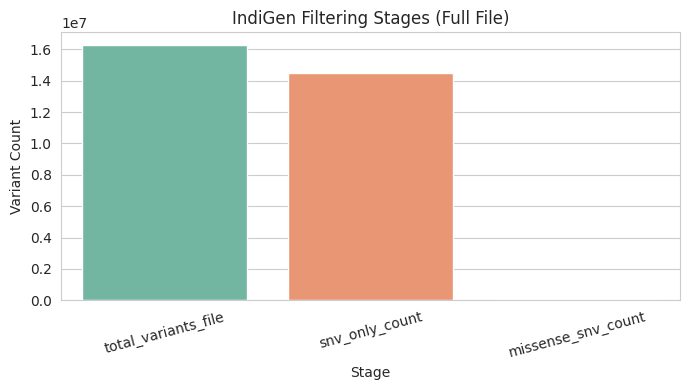

In [ ]:
indigen_result = extract_missense_snvs(
    vcf_path=INDIGEN_PATH,
    dataset_name='indigen',
    preview_rows=20
)

print('IndiGen filtering result (full file):')
print(f"Status: {indigen_result['status']}")
print(f"Total variants in file: {indigen_result['total_variants_file']:,}")
print(f"SNVs kept: {indigen_result['snv_count']:,}")
print(f"INDELs removed: {indigen_result['indel_removed_count']:,}")
print(f"Missense SNVs kept: {indigen_result['missense_snv_count']:,}")

step_df = pd.DataFrame([
    {'dataset': 'indigen', 'stage': 'total_variants_file', 'count': indigen_result['total_variants_file']},
    {'dataset': 'indigen', 'stage': 'snv_only_count', 'count': indigen_result['snv_count']},
    {'dataset': 'indigen', 'stage': 'missense_snv_count', 'count': indigen_result['missense_snv_count']}
])

print('\nStep-wise counts table:')
display(step_df)

plt.figure(figsize=(7, 4))
sns.barplot(data=step_df, x='stage', y='count', hue='stage', dodge=False, palette='Set2')
plt.title('IndiGen Filtering Stages (Full File)')
plt.xlabel('Stage')
plt.ylabel('Variant Count')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## Summary Table + Visualizations (IndiGen Full File)

Easy explanation:
- `total_variants_file`: all variants in the full file
- `snv_only_count`: after removing INDELs
- `missense_snv_count`: final filtered output
- Percent values help you explain conversion at each step

Final summary after SNV + missense filtering (full file, IMPACT/BIOTYPE ignored):


,dataset,scope,total_variants_file,snv_only_count,indels_removed_count,missense_snv_count,snv_percent_of_total,missense_percent_of_snv
0,indigen,full_file,16266617,14503055,1763562,94421,89.158397,0.651042


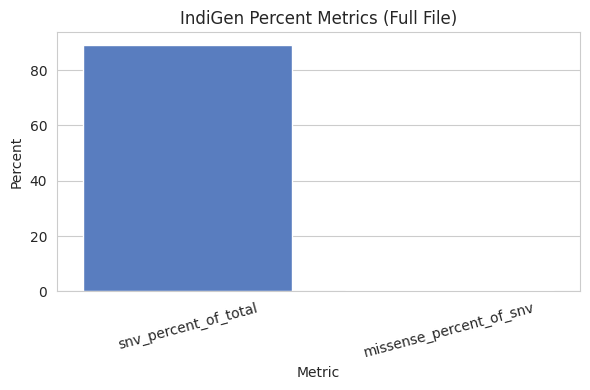

In [ ]:
summary_df = pd.DataFrame([
    {
        'dataset': 'indigen',
        'scope': 'full_file',
        'total_variants_file': indigen_result['total_variants_file'],
        'snv_only_count': indigen_result['snv_count'],
        'indels_removed_count': indigen_result['indel_removed_count'],
        'missense_snv_count': indigen_result['missense_snv_count'],
        'snv_percent_of_total': (
            indigen_result['snv_count'] / indigen_result['total_variants_file'] * 100
            if indigen_result['total_variants_file'] else np.nan
        ),
        'missense_percent_of_snv': (
            indigen_result['missense_snv_count'] / indigen_result['snv_count'] * 100
            if indigen_result['snv_count'] else np.nan
        )
    }
])

print('Final summary after SNV + missense filtering (full file, IMPACT/BIOTYPE ignored):')
display(summary_df)

percent_df = summary_df[['snv_percent_of_total', 'missense_percent_of_snv']].melt(
    var_name='metric',
    value_name='percent'
)

plt.figure(figsize=(6, 4))
sns.barplot(data=percent_df, x='metric', y='percent', hue='metric', dodge=False, palette='muted')
plt.title('IndiGen Percent Metrics (Full File)')
plt.xlabel('Metric')
plt.ylabel('Percent')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## View Extracted Variants (IndiGen)

Easy explanation:
- This table shows the filtered final records
- These are SNVs only and missense only
- Good to confirm the actual rows before downstream analysis

In [ ]:
indigen_preview_df = indigen_result.get('preview_df', pd.DataFrame())
indigen_full_df = indigen_result.get('missense_snv_df', pd.DataFrame())

print('IndiGen preview (top 20 rows):')
print(f"Rows shown: {len(indigen_preview_df):,}")
display(indigen_preview_df)

print('IndiGen final DataFrame info:')
print(f"Full rows: {len(indigen_full_df):,}")
print(f"Columns: {list(indigen_full_df.columns)}")
print('\nData types:')
print(indigen_full_df.dtypes if not indigen_full_df.empty else 'No data')

IndiGen preview (top 20 rows):
Rows shown: 20


,dataset,CHROM,POS,REF,ALT,FILTER_RULE
0,indigen,chr1,69518,G,T,SNV + missense_variant (IMPACT and BIOTYPE ign...
1,indigen,chr1,924573,C,G,SNV + missense_variant (IMPACT and BIOTYPE ign...
2,indigen,chr1,924669,G,T,SNV + missense_variant (IMPACT and BIOTYPE ign...
3,indigen,chr1,935779,G,C,SNV + missense_variant (IMPACT and BIOTYPE ign...
4,indigen,chr1,935894,C,T,SNV + missense_variant (IMPACT and BIOTYPE ign...
5,indigen,chr1,939367,T,C,SNV + missense_variant (IMPACT and BIOTYPE ign...
6,indigen,chr1,941239,C,T,SNV + missense_variant (IMPACT and BIOTYPE ign...
7,indigen,chr1,941255,C,T,SNV + missense_variant (IMPACT and BIOTYPE ign...
8,indigen,chr1,942227,C,T,SNV + missense_variant (IMPACT and BIOTYPE ign...
9,indigen,chr1,942641,C,G,SNV + missense_variant (IMPACT and BIOTYPE ign...


IndiGen final DataFrame info:
Full rows: 94,421
Columns: ['dataset', 'CHROM', 'POS', 'REF', 'ALT', 'FILTER_RULE']

Data types:
dataset        object
CHROM          object
POS             int64
REF            object
ALT            object
FILTER_RULE    object
dtype: object


## Export Final Filtered File (IndiGen)

Easy explanation:
- Set `SAVE_OUTPUTS = True` if you want CSV output
- This exports only IndiGen missense SNVs after SNV filtering

In [ ]:
# Create a clean export copy with only the required columns
required_cols = ['CHROM', 'POS', 'REF', 'ALT']
indigen_export_df = indigen_full_df[required_cols].copy() if all(c in indigen_full_df.columns for c in required_cols) else pd.DataFrame(columns=required_cols)

print('Prepared export DataFrame with only required fields:')
print(f'Columns: {list(indigen_export_df.columns)}')
print(f'Rows: {len(indigen_export_df):,}')
display(indigen_export_df.head(20))

Prepared export DataFrame with only required fields:
Columns: ['CHROM', 'POS', 'REF', 'ALT']
Rows: 94,421


,CHROM,POS,REF,ALT
0,chr1,69518,G,T
1,chr1,924573,C,G
2,chr1,924669,G,T
3,chr1,935779,G,C
4,chr1,935894,C,T
5,chr1,939367,T,C
6,chr1,941239,C,T
7,chr1,941255,C,T
8,chr1,942227,C,T
9,chr1,942641,C,G


In [ ]:
SAVE_OUTPUTS = True
OUTPUT_DIR = f'{BASE}/DATA/filtered_outputs'

if SAVE_OUTPUTS:
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    out_path = f'{OUTPUT_DIR}/indigen_fullfile_missense_snvs_only.csv'
    indigen_export_df.to_csv(out_path, index=False)
    print(f'Saved: {out_path}')
else:
    print('SAVE_OUTPUTS is False. No file was written.')

Saved: /content/drive/MyDrive/FYP_DATA/DATA/filtered_outputs/indigen_fullfile_missense_snvs_only.csv


In [15]:
indigen_export_df.shape

(94421, 4)